# Q. Analytical Derivation

Consider the filter model
\begin{align*}
x^{-}_k &= A_{k-1}\,x^{+}_{k-1} + G_{k-1}\,w_{k-1}, \\
y^{-}_k &= H_k\,x^{-}_k + z_k,
\end{align*}
where
$$x^{+}_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1}),$$

Answer the followings:

1. Show that
$$x_k^- \sim \mathscr{N}(m_k^-, P_k^-),$$
where
$$m_k^- = A_{k-1}m_{k-1},$$
and
$$
P_k^- = A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T.
$$

2. Show that
$$y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m).$$

3. Show that
$$\begin{bmatrix} x_k^- \\ y^{-}_k \end{bmatrix} \sim \mathscr{N}\left(
\begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix},
\begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix}
\right).$$

4. Show that
$$x^{+}_k\triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k),$$
where the updated mean $m_k$ and updated covariance $P_k$ are given by:
\begin{align*}
K_k &\triangleq P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}, \\
m_k &= m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-), \\
P_k &= (I - K_k H_k) P_k^-.
\end{align*}

5. Find
$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}]$  and
$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k})$.

### 1. Distribution of $x_k^-$

Given the state transition equation:
$$x_k^- = A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}$$

where $x_{k-1}^+ \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, \Sigma_p)$ are independent Gaussian random variables.

**Mean ($m_k^-$):**
$$\begin{align*}
m_k^- &= \mathbb{E}[x_k^-] \\
&= \mathbb{E}[A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1}] \\
&= A_{k-1}\mathbb{E}[x_{k-1}^+] + G_{k-1}\mathbb{E}[w_{k-1}] \\
&= A_{k-1}m_{k-1} + G_{k-1}(0) \\
&= A_{k-1}m_{k-1}
\end{align*}$$

**Covariance ($P_k^-$):**
$$\begin{align*}
P_k^- &= \text{Var}(x_k^-) \\
&= \text{Var}(A_{k-1}x_{k-1}^+ + G_{k-1}w_{k-1})
\end{align*}$$
Since $x_{k-1}^+$ and $w_{k-1}$ are independent, the cross-covariance terms vanish:
$$\begin{align*}
P_k^- &= A_{k-1}\text{Var}(x_{k-1}^+)A_{k-1}^T + G_{k-1}\text{Var}(w_{k-1})G_{k-1}^T \\
&= A_{k-1}P_{k-1}A_{k-1}^T + G_{k-1}\Sigma_p G_{k-1}^T
\end{align*}$$

Thus, $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$.

---

### 2. Distribution of $y_k^-$

Given the measurement equation:
$$y_k^- = H_k x_k^- + z_k$$

where $x_k^- \sim \mathscr{N}(m_k^-, P_k^-)$ and $z_k \sim \mathscr{N}(0, \Sigma_m)$ are independent Gaussian random variables.

**Mean:**
$$\begin{align*}
\mathbb{E}[y_k^-] &= \mathbb{E}[H_k x_k^- + z_k] \\
&= H_k \mathbb{E}[x_k^-] + \mathbb{E}[z_k] \\
&= H_k m_k^- + 0 \\
&= H_k m_k^-
\end{align*}$$

**Covariance:**
$$\begin{align*}
\text{Var}(y_k^-) &= \text{Var}(H_k x_k^- + z_k) \\
&= H_k \text{Var}(x_k^-)H_k^T + \text{Var}(z_k) \\
&= H_k P_k^- H_k^T + \Sigma_m
\end{align*}$$

Thus, $y_k^- \sim \mathscr{N}(H_k m_k^-, H_k P_k^- H_k^T + \Sigma_m)$.

---

### 3. Joint Distribution of $\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix}$

The joint distribution of two linearly transformed Gaussian vectors is a multivariate Gaussian vector of the form:
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} \mathbb{E}[x_k^-] \\ \mathbb{E}[y_k^-] \end{bmatrix}, \begin{bmatrix} \text{Var}(x_k^-) & \text{Cov}(x_k^-, y_k^-) \\ \text{Cov}(y_k^-, x_k^-) & \text{Var}(y_k^-) \end{bmatrix} \right)$$

We compute the cross-covariance term $\text{Cov}(x_k^-, y_k^-)$:
$$\begin{align*}
\text{Cov}(x_k^-, y_k^-) &= \mathbb{E}\left[(x_k^- - m_k^-)(y_k^- - H_k m_k^-)^T\right] \\
&= \mathbb{E}\left[(x_k^- - m_k^-)(H_k x_k^- + z_k - H_k m_k^-)^T\right] \\
&= \mathbb{E}\left[(x_k^- - m_k^-)(x_k^- - m_k^-)^T H_k^T + (x_k^- - m_k^-)z_k^T\right]
\end{align*}$$

Since $x_k^-$ and $z_k$ are uncorrelated, $\mathbb{E}[(x_k^- - m_k^-)z_k^T] = 0$:
$$\begin{align*}
\text{Cov}(x_k^-, y_k^-) &= \mathbb{E}\left[(x_k^- - m_k^-)(x_k^- - m_k^-)^T\right] H_k^T \\
&= P_k^- H_k^T
\end{align*}$$

By symmetry, $\text{Cov}(y_k^-, x_k^-) = [\text{Cov}(x_k^-, y_k^-)]^T = H_k P_k^-$.

Substituting the components back yields:
$$\begin{bmatrix} x_k^- \\ y_k^- \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} m_k^- \\ H_k m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- H_k^T \\ H_k P_k^- & H_k P_k^- H_k^T + \Sigma_m \end{bmatrix} \right)$$

---

### 4. Conditional Distribution of $x_k^+$

Using the standard Gaussian conditioning identities, if:
$$\begin{bmatrix} X \\ Y \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} \mu_X \\ \mu_Y \end{bmatrix}, \begin{bmatrix} \Sigma_{XX} & \Sigma_{XY} \\ \Sigma_{YX} & \Sigma_{YY} \end{bmatrix} \right)$$

Then the conditional distribution $(X \mid Y = y)$ is $\mathscr{N}(\mu_{X|Y}, \Sigma_{X|Y})$, where:
$$\mu_{X|Y} = \mu_X + \Sigma_{XY} \Sigma_{YY}^{-1} (y - \mu_Y)$$
$$\Sigma_{X|Y} = \Sigma_{XX} - \Sigma_{XY} \Sigma_{YY}^{-1} \Sigma_{YX}$$

Mapping the elements from our joint system:
* $\mu_X = m_k^-$
* $\mu_Y = H_k m_k^-$
* $\Sigma_{XX} = P_k^-$
* $\Sigma_{XY} = P_k^- H_k^T$
* $\Sigma_{YX} = H_k P_k^-$
* $\Sigma_{YY} = H_k P_k^- H_k^T + \Sigma_m$

Let the Kalman Gain be defined as:
$$K_k \triangleq \Sigma_{XY} \Sigma_{YY}^{-1} = P_k^- H_k^T (H_k P_k^- H_k^T + \Sigma_m)^{-1}$$

Substituting $K_k$ into the updated mean formula:
$$m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

Substituting $K_k$ into the updated covariance formula:
$$P_k = P_k^- - K_k (H_k P_k^-) = (I - K_k H_k) P_k^-$$

Thus, $x^{+}_k \triangleq (x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) \sim \mathscr{N}(m_k, P_k)$.

---

### 5. Conditional Expected Value and Variance

Based directly on the conditional distribution properties proven in step 4:

$$\mathbb{E}[x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}] = m_k = m_k^- + K_k (y^{\mathrm{obs}}_{k} - H_k m_k^-)$$

$$\text{Var}(x^{-}_k \mid y^{-}_k = y^{\mathrm{obs}}_{k}) = P_k = (I - K_k H_k) P_k^-$$

# Q. 1-D Example

Consider the scalar linear-Gaussian filter model
\begin{aligned}
x^-_k &= a\,x^+_{k-1} + w_{k-1},\qquad w_{k-1}\sim\mathscr N(0,q),\\
y^-_k &= h\,x^-_k + z_k,\qquad\;\;\;\; z_k\sim\mathscr N(0,r),
\end{aligned}
with prior $x_0\sim \mathscr{N}(m_0,P_0)$. Define $Y_{k}=\{y^{\mathrm{obs}}_1,\dots,y^{\mathrm{obs}}_{k}\}$.

Answer the following:

1. Show that
\begin{aligned}
m_k^- &= a\,m_{k-1},\\
P_k^- &= a^2 P_{k-1} + q.
\end{aligned}

2. Show that
\begin{aligned}
m_k &= m_k^- + K_k\,v_k
= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr),\\
P_k &= (1 - K_k h)\,P_k^-
= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^- .
\end{aligned}

3. Show that the predictive measurement distribution (before seeing $y_k$):
\begin{align*}
p(y^-_k | Y_{k-1})=\mathscr N\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr).
\end{align*}

4. Show that the posterior-predictive measurement distribution (after filtering on $y_k$):
\begin{align*}
p(y^-_k\mid Y_k)=\mathscr N\bigl(h\,m_k,\; h^2 P_k + r\bigr).
\end{align*}

5. For suitable numerical values for $a,q,h,r$ animate the above to prior distribution and the posterior distribution.

### 1. State Prediction Step (Prior Distribution)

Given the scalar state equation:
$$x^-_k = a\,x^+_{k-1} + w_{k-1}$$

where $x^+_{k-1} \sim \mathscr{N}(m_{k-1}, P_{k-1})$ and $w_{k-1} \sim \mathscr{N}(0, q)$ are independent random variables.

**Predicted Mean ($m_k^-$):**
$$\begin{align*}
m_k^- &= \mathbb{E}[x^-_k] \\
&= \mathbb{E}[a\,x^+_{k-1} + w_{k-1}] \\
&= a\,\mathbb{E}[x^+_{k-1}] + \mathbb{E}[w_{k-1}] \\
&= a\,m_{k-1} + 0 \\
&= a\,m_{k-1}
\end{align*}$$

**Predicted Covariance ($P_k^-$):**
$$\begin{align*}
P_k^- &= \text{Var}(x^-_k) \\
&= \text{Var}(a\,x^+_{k-1} + w_{k-1})
\end{align*}$$
Since $x^+_{k-1}$ and $w_{k-1}$ are mutually independent, their covariance is zero:
$$\begin{align*}
P_k^- &= a^2\,\text{Var}(x^+_{k-1}) + \text{Var}(w_{k-1}) \\
&= a^2 P_{k-1} + q
\end{align*}$$

---

### 2. Measurement Update Step (Posterior Distribution)

The joint distribution of the state $x^-_k$ and measurement $y^-_k$ is given by:
$$\begin{bmatrix} x^-_k \\ y^-_k \end{bmatrix} \sim \mathscr{N}\left( \begin{bmatrix} m_k^- \\ h\,m_k^- \end{bmatrix}, \begin{bmatrix} P_k^- & P_k^- h \\ h P_k^- & h^2 P_k^- + r \end{bmatrix} \right)$$

Let the innovation covariance be $S_k = h^2 P_k^- + r$. Applying the standard Gaussian conditioning rules for $x^+_k = (x^-_k \mid y^-_k = y^{\mathrm{obs}}_k)$:

**Kalman Gain ($K_k$):**
$$K_k = \frac{\text{Cov}(x^-_k, y^-_k)}{\text{Var}(y^-_k)} = \frac{P_k^- h}{S_k} = \frac{P_k^- h}{h^2 P_k^- + r}$$

**Updated Mean ($m_k$):**
$$\begin{align*}
m_k &= m_k^- + K_k\,v_k \\
&= m_k^- + \frac{P_k^- h}{S_k}\bigl(y^{\mathrm{obs}}_k - h\,m_k^-\bigr)
\end{align*}$$

**Updated Covariance ($P_k$):**
$$\begin{align*}
P_k &= P_k^- - K_k\,\text{Cov}(y^-_k, x^-_k) \\
&= P_k^- - K_k (h P_k^-) \\
&= (1 - K_k h)\,P_k^- \\
&= \Bigl(1 - \frac{P_k^- h^2}{S_k}\Bigr) P_k^-
\end{align*}$$

---

### 3. Predictive Measurement Distribution

Before seeing the measurement $y^{\mathrm{obs}}_k$, the conditional distribution depends on past history $Y_{k-1}$. The measurement model is:
$$y^-_k = h\,x^-_k + z_k$$

Given $p(x^-_k \mid Y_{k-1}) = \mathscr{N}(m_k^-, P_k^-)$, and $z_k \sim \mathscr{N}(0,r)$ is independent of $Y_{k-1}$ and $x^-_k$:

**Mean:**
$$\mathbb{E}[y^-_k \mid Y_{k-1}] = \mathbb{E}[h\,x^-_k + z_k \mid Y_{k-1}] = h\,m_k^- + 0 = h\,m_k^-$$

**Covariance:**
$$\text{Var}(y^-_k \mid Y_{k-1}) = \text{Var}(h\,x^-_k + z_k \mid Y_{k-1}) = h^2 P_k^- + r$$

Thus, the predictive measurement distribution is:
$$p(y^-_k \mid Y_{k-1}) = \mathscr{N}\bigl(h\,m_k^-,\; h^2 P_k^- + r\bigr)$$

---

### 4. Posterior-Predictive Measurement Distribution

After filtering on the actual observation $y^{\mathrm{obs}}_k$, the state distribution updates to the posterior $p(x^-_k \mid Y_k) = \mathscr{N}(m_k, P_k)$. The distribution of an arbitrary hypothetical measurement $y^-_k$ evaluated under this current posterior state is:

**Mean:**
$$\mathbb{E}[y^-_k \mid Y_k] = \mathbb{E}[h\,x^-_k + z_k \mid Y_k] = h\,\mathbb{E}[x^-_k \mid Y_k] = h\,m_k$$

**Covariance:**
$$\text{Var}(y^-_k \mid Y_k) = \text{Var}(h\,x^-_k + z_k \mid Y_k) = h^2 \text{Var}(x^-_k \mid Y_k) + \text{Var}(z_k) = h^2 P_k + r$$

Thus, the posterior-predictive measurement distribution is:
$$p(y^-_k \mid Y_k) = \mathscr{N}\bigl(h\,m_k,\; h^2 P_k + r\bigr)$$

---

### 5. Numerical Simulation & Animation Code
Run the following python code block to view the dynamic transition between the state prior (prediction) and state posterior (update) distributions.

# Q. 2D-Position Estimation

## Part A

Consider a two-dimensional constant-velocity dynamical system. The hidden state at time step $k$ is

$$
x_k =
\begin{bmatrix}
p_x(k)\\
p_y(k)\\
v_x(k)\\
v_y(k)
\end{bmatrix},
$$

where $(p_x(k),p_y(k))$ denote the position components and $(v_x(k),v_y(k))$ denote the velocity components.

The measurement consists only of the two position components:

$$
y_k =
\begin{bmatrix}
p_x^{\mathrm{meas}}(k)\\
p_y^{\mathrm{meas}}(k)
\end{bmatrix}.
$$

The linear Gaussian state-space filter model is

$$
x^-_k = A x^+_{k-1} + G w_{k-1},
$$

$$
y^-_k = Hx^+_k + z_k,
$$

where

$$
w_{k-1} \sim \mathscr{N}(0,\Sigma_p),
\qquad
z_k \sim \mathscr{N}(0,\Sigma_m).
$$

The process noise sequence $w_k$, measurement noise sequence $z_k$, and the initial state are assumed mutually independent.

Show that:

$$
A =
\begin{bmatrix}
1 & 0 & \Delta t & 0\\
0 & 1 & 0 & \Delta t\\
0 & 0 & 1 & 0\\
0 & 0 & 0 & 1
\end{bmatrix},
$$



$$
H =
\begin{bmatrix}
1 & 0 & 0 & 0\\
0 & 1 & 0 & 0
\end{bmatrix},
$$

and

$$
G =
\begin{bmatrix}
\frac{1}{2}\Delta t^2 & 0\\
0 & \frac{1}{2}\Delta t^2\\
\Delta t & 0\\
0 & \Delta t
\end{bmatrix}.
$$

### Kinematic Derivation of the State-Space Matrices

To determine the matrices $A$, $G$, and $H$, we analyze the continuous-time physics of a constant-velocity (CV) system with zero-order acceleration noise (jerk/force perturbations), and then map the discrete-time state transitions to the state vector:

$$x_k = \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix}$$

---

### 1. Derivation of the State Transition Matrix $A$ and Noise Coupling Matrix $G$

Under a constant-velocity model with a sampling interval of $\Delta t$, the position at time step $k$ depends linearly on the previous position and the distance traveled due to velocity over $\Delta t$. Assuming a constant acceleration vector $a_{k-1} = \begin{bmatrix} a_x(k-1) \\ a_y(k-1) \end{bmatrix}$ acts as a random perturbation over the interval, the fundamental kinematic equations of motion for each independent coordinate ($x$ and $y$) are:

$$\begin{align*}
p_x(k) &= p_x(k-1) + v_x(k-1)\Delta t + \frac{1}{2}a_x(k-1)\Delta t^2 \\
p_y(k) &= p_y(k-1) + v_y(k-1)\Delta t + \frac{1}{2}a_y(k-1)\Delta t^2 \\
v_x(k) &= v_x(k-1) + a_x(k-1)\Delta t \\
v_y(k) &= v_y(k-1) + a_y(k-1)\Delta t
\end{align*}$$

Let the process noise vector represent the random acceleration vector driving the system uncertainty:
$$w_{k-1} = \begin{bmatrix} a_x(k-1) \\ a_y(k-1) \end{bmatrix}$$

We separate the deterministic transition components (depending on $x_{k-1}^+$) from the stochastic process noise injection components (depending on $w_{k-1}$) to express the system in matrix-vector form $x_k^- = A x_{k-1}^+ + G w_{k-1}$:

$$\begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix} \begin{bmatrix} p_x(k-1) \\ p_y(k-1) \\ v_x(k-1) \\ v_y(k-1) \end{bmatrix} + \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix} \begin{bmatrix} a_x(k-1) \\ a_y(k-1) \end{bmatrix}$$

Matching the coefficients directly verifies the structural forms of $A$ and $G$:
$$A = \begin{bmatrix} 1 & 0 & \Delta t & 0 \\ 0 & 1 & 0 & \Delta t \\ 0 & 0 & 1 & 0 \\ 0 & 0 & 0 & 1 \end{bmatrix}, \qquad G = \begin{bmatrix} \frac{1}{2}\Delta t^2 & 0 \\ 0 & \frac{1}{2}\Delta t^2 \\ \Delta t & 0 \\ 0 & \Delta t \end{bmatrix}$$

---

### 2. Derivation of the Measurement Matrix $H$

The measurement vector $y_k$ contains only the direct physical observation of the position coordinates. The relationship between the actual hidden state and the noise-free ideal measurement is:

$$\begin{align*}
p_x^{\mathrm{meas}}(k) &= 1 \cdot p_x(k) + 0 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k) \\
p_y^{\mathrm{meas}}(k) &= 0 \cdot p_x(k) + 1 \cdot p_y(k) + 0 \cdot v_x(k) + 0 \cdot v_y(k)
\end{align*}$$

Expressing this measurement system explicitly as a linear transformation matrix equation $y_k^- = H x_k^+ + z_k$:

$$\begin{bmatrix} p_x^{\mathrm{meas}}(k) \\ p_y^{\mathrm{meas}}(k) \end{bmatrix} = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix} \begin{bmatrix} p_x(k) \\ p_y(k) \\ v_x(k) \\ v_y(k) \end{bmatrix} + z_k$$

Matching the linear transformation coefficients yields the standard projection matrix $H$:
$$H = \begin{bmatrix} 1 & 0 & 0 & 0 \\ 0 & 1 & 0 & 0 \end{bmatrix}$$

## Part B

Develop a python based method to filter a sequence of noisy GPS obtained position meaurements.

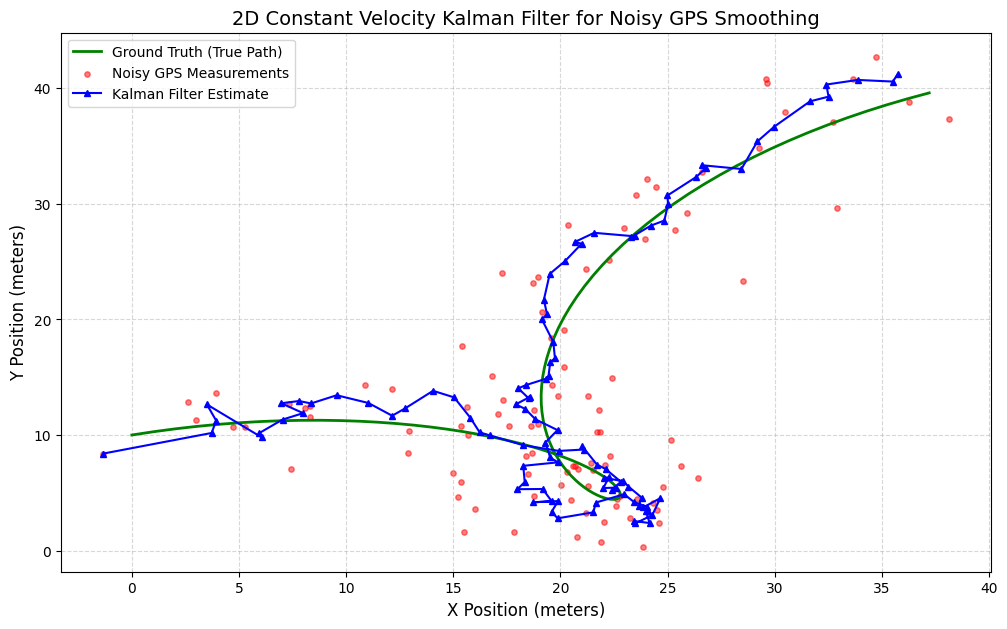

In [1]:
import numpy as np
import matplotlib.pyplot as plt

class GPSKalmanFilter2D:
    def __init__(self, dt, process_noise_std=0.1, measurement_noise_std=2.0):
        """
        Initializes a 2D Constant-Velocity Kalman Filter.

        State vector x: [pos_x, pos_y, vel_x, vel_y]^T
        Measurement vector y: [pos_x_meas, pos_y_meas]^T
        """
        self.dt = dt

        # State Transition Matrix (A)
        self.A = np.array([
            [1, 0, dt,  0],
            [0, 1,  0, dt],
            [0, 0,  1,  0],
            [0, 0,  0,  1]
        ])

        # Noise Coupling Matrix (G)
        self.G = np.array([
            [0.5 * dt**2, 0],
            [0, 0.5 * dt**2],
            [dt, 0],
            [0, dt]
        ])

        # Measurement Matrix (H)
        self.H = np.array([
            [1, 0, 0, 0],
            [0, 1, 0, 0]
        ])

        # Process Noise Covariance (Q = G * Sigma_p * G^T)
        sigma_p = process_noise_std**2
        self.Q = self.G @ (np.eye(2) * sigma_p) @ self.G.T

        # Measurement Noise Covariance (R)
        self.R = np.eye(2) * (measurement_noise_std**2)

        # Initial State Estimate (x) and Covariance (P)
        self.x = np.zeros((4, 1))
        self.P = np.eye(4) * 10.0  # High initial uncertainty

        self.initialized = False

    def initialize(self, init_x, init_y):
        """Initializes the filter with the first GPS measurement."""
        self.x = np.array([[init_x], [init_y], [0.0], [0.0]])
        self.P = np.eye(4) * 10.0
        self.initialized = True

    def predict(self):
        """Predicts the next state and covariance (Time Update)."""
        self.x = self.A @ self.x
        self.P = self.A @ self.P @ self.A.T + self.Q
        return self.x

    def update(self, z):
        """Updates the state with a new measurement (Measurement Update)."""
        # Innovation/Residual
        v = z - (self.H @ self.x)

        # Innovation Covariance
        S = self.H @ self.P @ self.H.T + self.R

        # Kalman Gain
        K = self.P @ self.H.T @ np.linalg.inv(S)

        # State and Covariance Correction
        self.x = self.x + K @ v
        self.P = (np.eye(4) - K @ self.H) @ self.P
        return self.x

    def filter_sequence(self, measurements):
        """
        Filters an entire array of noisy measurements.
        measurements: shape (N, 2) array of [x, y] coordinates
        """
        estimated_states = []

        for z_raw in measurements:
            z = z_raw.reshape(2, 1)

            if not self.initialized:
                self.initialize(z[0, 0], z[1, 0])
                estimated_states.append(self.x.copy())
                continue

            self.predict()
            self.update(z)
            estimated_states.append(self.x.copy())

        return np.array(estimated_states).squeeze()

# ==========================================
# Example Simulation & Testing
# ==========================================
if __name__ == "__main__":
    # Parameters
    N = 100         # Number of timesteps
    dt = 1.0        # Time step (e.g., 1 second interval GPS updates)
    r_std = 2.5     # Simulated GPS noise (meters) standard deviation
    q_std = 0.1     # System acceleration standard deviation

    # 1. Generate an ideal ground truth trajectory (e.g., circular path)
    t = np.linspace(0, 20, N)
    true_x = 10 * np.sin(0.3 * t) + 2 * t
    true_y = 10 * np.cos(0.3 * t) + 1.5 * t

    # 2. Add Gaussian noise to simulate realistic GPS degradation
    noise_x = np.random.normal(0, r_std, N)
    noise_y = np.random.normal(0, r_std, N)
    noisy_measurements = np.column_stack((true_x + noise_x, true_y + noise_y))

    # 3. Apply the Kalman Filter
    kf = GPSKalmanFilter2D(dt=dt, process_noise_std=q_std, measurement_noise_std=r_std)
    filtered_results = kf.filter_sequence(noisy_measurements)

    # Extract positions
    filtered_x = filtered_results[:, 0]
    filtered_y = filtered_results[:, 1]

    # 4. Plotting results
    plt.figure(figsize=(12, 7))
    plt.plot(true_x, true_y, 'g-', lw=2, label='Ground Truth (True Path)')
    plt.scatter(noisy_measurements[:, 0], noisy_measurements[:, 1], color='red', alpha=0.5, s=15, label='Noisy GPS Measurements')
    plt.plot(filtered_x, filtered_y, 'b-^', lw=1.5, markersize=4, label='Kalman Filter Estimate')

    plt.title('2D Constant Velocity Kalman Filter for Noisy GPS Smoothing', fontsize=14)
    plt.xlabel('X Position (meters)', fontsize=12)
    plt.ylabel('Y Position (meters)', fontsize=12)
    plt.legend(loc='best')
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.show()